In [1]:
import kagglehub

# Download the Spam Mails Dataset (contains email text)
path = kagglehub.dataset_download("venky73/spam-mails-dataset")

print("Path to dataset files:", path)

/Users/vaishnavishinde/anaconda3/envs/nlp/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.86M/1.86M [00:01<00:00, 1.01MB/s]

Extracting files...
Path to dataset files: /Users/vaishnavishinde/.cache/kagglehub/datasets/venky73/spam-mails-dataset/versions/1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [3]:

df = pd.read_csv(f"{path}/spam_ham_dataset.csv")


df = df[['label', 'text']]
df.columns = ['label', 'message']

In [4]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [5]:
df.head(10)

,label,message
0,0,Subject: enron methanol ; meter # : 988291\r\n...
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,1,"Subject: photoshop , windows , office . cheap ..."
4,0,Subject: re : indian springs\r\nthis deal is t...
5,0,Subject: ehronline web address change\r\nthis ...
6,0,Subject: spring savings certificate - take 30 ...
7,1,Subject: looking for medication ? we ` re the ...
8,0,Subject: noms / actual flow for 2 / 26\r\nwe a...
9,0,"Subject: nominations for oct . 21 - 23 , 2000\..."


In [6]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vaishnavishinde/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vaishnavishinde/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/vaishnavishinde/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def clean_text(text):
    text = text.replace('Subject: ', '')
    text = text.lower()
    text = nltk.word_tokenize(text)

    text = [word for word in text if word.isalnum()]

    text = [word for word in text if word not in stopwords.words('english')]

    text = [ps.stem(word) for word in text]



    return " ".join(text)

In [8]:
df['cleaned'] = df['message'].apply(clean_text)
df.head()

,label,message,cleaned
0,0,Subject: enron methanol ; meter # : 988291\r\n...,enron methanol meter 988291 follow note gave m...
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see...",hpl nom januari 9 2001 see attach file hplnol ...
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar...",neon retreat ho ho ho around wonder time year ...
3,1,"Subject: photoshop , windows , office . cheap ...",photoshop window offic cheap main trend abas d...
4,0,Subject: re : indian springs\r\nthis deal is t...,indian spring deal book teco pvr revenu unders...


In [9]:
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(df['cleaned'])
y = df['label']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [11]:
nb = MultinomialNB()
svm = SVC(probability=True)
lr = LogisticRegression()

In [12]:
nb.fit(X_train, y_train)
svm.fit(X_train, y_train)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
with open("models/naive_bayes_model.pkl", "wb") as f:
    pickle.dump(nb, f)
with open("models/svm_model.pkl", "wb") as f:
    pickle.dump(svm, f)
with open("models/logistic_regression_model.pkl", "wb") as f:
    pickle.dump(lr, f)
with open("models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

In [ ]:
# with open("models/label_encoder.pkl", "wb") as f:
#     pickle.dump(encoder, f)

In [14]:
y_pred_nb = nb.predict(X_test)
y_pred_svm = svm.predict(X_test)
y_pred_lr = lr.predict(X_test)

In [15]:
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_svm = accuracy_score(y_test, y_pred_svm)

In [16]:
print("Naive Bayes Accuracy:", acc_nb)
print("Logistic Regression Accuracy:", acc_lr)
print("SVM Accuracy:", acc_svm)

Naive Bayes Accuracy: 0.957487922705314
Logistic Regression Accuracy: 0.9855072463768116
SVM Accuracy: 0.9884057971014493


In [17]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_svm = confusion_matrix(y_test, y_pred_svm)

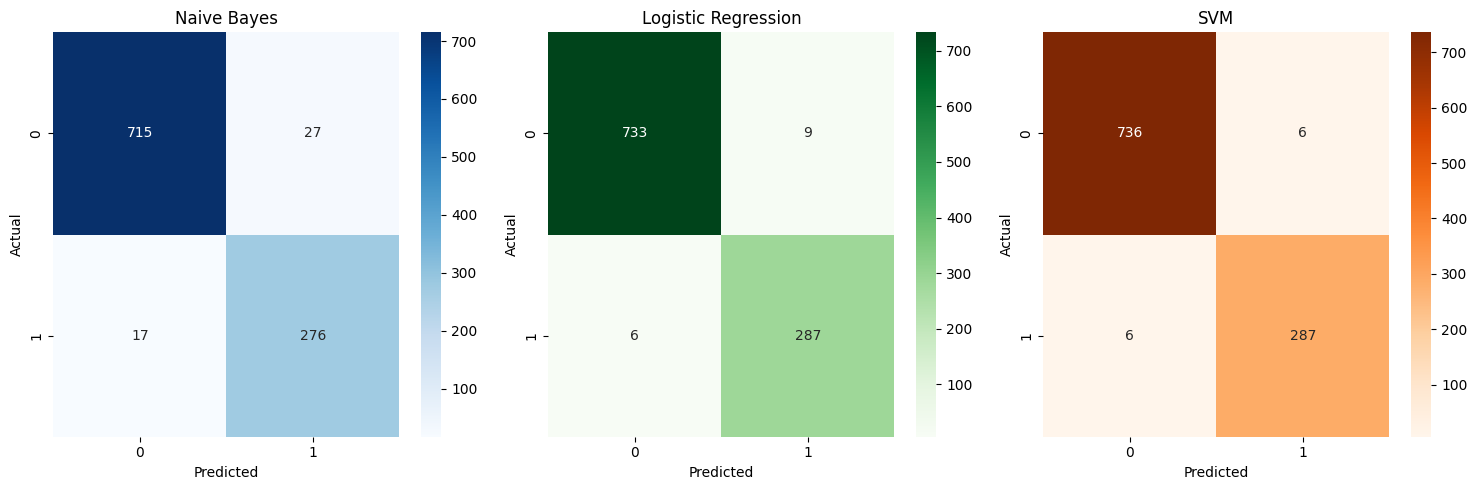

In [18]:
plt.figure(figsize=(15,5))

# Naive Bayes
plt.subplot(1,3,1)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Logistic Regression
plt.subplot(1,3,2)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title("Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# SVM
plt.subplot(1,3,3)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges')
plt.title("SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

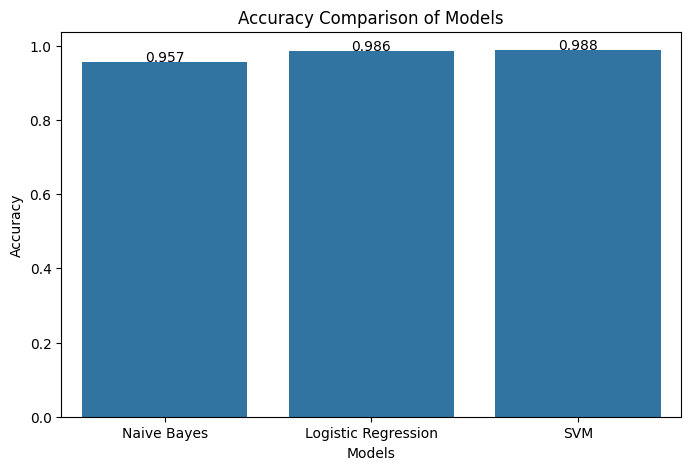

In [19]:
plt.figure(figsize=(8,5))

models = ['Naive Bayes', 'Logistic Regression', 'SVM']
accuracy = [acc_nb, acc_lr, acc_svm]

ax = sns.barplot(x=models, y=accuracy)

for i, v in enumerate(accuracy):
    ax.text(i, v + 0.001, f"{v:.3f}", ha='center')

plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()